In [1]:
import pandas as pd
import numpy as np

content_df = pd.read_parquet("../data/processed/content_features.parquet")
interactions = pd.read_parquet("../data/processed/interactions.parquet")

print(f"Total artists: {len(content_df):,}")
print(f"Artists with content features: {content_df['has_content_features'].sum():,}")

Total artists: 145,778
Artists with content features: 7,505


In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.recommenders.content_based import ContentBasedRecommender

cb_rec = ContentBasedRecommender()
cb_rec.fit(content_df, interactions)

Computing similarity matrix for 7,505 artists...
Similarity matrix shape: (7505, 7505)
Memory usage: 225.3 MB


In [5]:

test_artists = ["radiohead", "coldplay", "metallica"]

for artist in test_artists:
    print(f"\nArtists similar to '{artist}':")
    recs = cb_rec.similar_artists(artist, k=5)
    print(recs.to_string(index=False))


Artists similar to 'radiohead':
 artist_name  similarity_score
silent poets            0.9666
  mad season            0.9640
  cinderella            0.9521
        styx            0.9434
      mate.o            0.9429

Artists similar to 'coldplay':
 artist_name  similarity_score
phil wickham            0.9505
   starfield            0.9472
     di-rect            0.9421
     direc-t            0.9421
 queensrÿche            0.9349

Artists similar to 'metallica':
 artist_name  similarity_score
     volbeat            0.9609
 soundgarden            0.9472
killing joke            0.9438
sick puppies            0.9408
     soulfly            0.9404


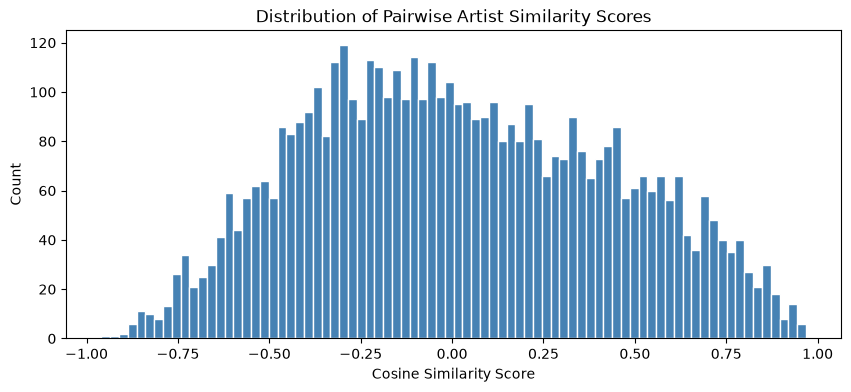

Mean similarity:   0.0192
Median similarity: -0.0122
Std deviation:     0.4116
% scores > 0.8:    2.46%
% scores > 0.5:    15.24%


In [6]:

import matplotlib.pyplot as plt


np.random.seed(42)
n = len(cb_rec.matched_artists)
sample_i = np.random.randint(0, n, 5000)
sample_j = np.random.randint(0, n, 5000)
mask = sample_i != sample_j  # exclude diagonal
sample_scores = cb_rec.similarity_matrix[sample_i[mask], sample_j[mask]]

plt.figure(figsize=(10, 4))
plt.hist(sample_scores, bins=80, color="steelblue", edgecolor="white")
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Count")
plt.title("Distribution of Pairwise Artist Similarity Scores")
plt.savefig("outputs/figures/similarity_distribution.png", dpi=150)
plt.show()

print(f"Mean similarity:   {sample_scores.mean():.4f}")
print(f"Median similarity: {np.median(sample_scores):.4f}")
print(f"Std deviation:     {sample_scores.std():.4f}")
print(f"% scores > 0.8:    {(sample_scores > 0.8).mean()*100:.2f}%")
print(f"% scores > 0.5:    {(sample_scores > 0.5).mean()*100:.2f}%")

In [8]:

sample_user = interactions["user_id"].iloc[100]


user_artists = interactions[interactions["user_id"] == sample_user][["artist_name", "plays"]]
user_artists_matched = user_artists[
    user_artists["artist_name"].isin(cb_rec.matched_artists)
].sort_values("plays", ascending=False)

print(f"User: {sample_user[:16]}...")
print(f"Total artists: {len(user_artists)}")
print(f"Artists with content features: {len(user_artists_matched)}")
print(f"\nTop listened (with content features):")
print(user_artists_matched.head(8).to_string(index=False))


profile = cb_rec._build_user_profile(sample_user)

if profile is not None:
    from src.recommenders.content_based import AUDIO_FEATURES
    profile_series = pd.Series(profile, index=AUDIO_FEATURES)
    print("\nUser Taste Profile Vector (scaled units):")
    print(profile_series.round(4))

User: 0000f687d4fe9c1e...
Total artists: 49
Artists with content features: 26

Top listened (with content features):
         artist_name  plays
     black eyed peas     12
       nelly furtado     11
      antonio orozco     10
        marc anthony      8
     manuel carrasco      7
la oreja de van gogh      6
              juanes      6
             melendi      6

User Taste Profile Vector (scaled units):
danceability        0.6229
energy              0.2084
loudness            0.5574
speechiness        -0.1778
acousticness       -0.0906
instrumentalness   -0.5989
liveness           -0.0938
valence             0.4483
tempo               0.0381
dtype: float64


In [10]:
recs = cb_rec.recommend_for_user(sample_user, k=10)
print(f"\nContent-Based Recommendations for user {sample_user[:16]}...")
print(recs.to_string(index=False))


from src.recommenders.popularity import PopularityRecommender
import pickle

popularity_df = pd.read_parquet("../data/processed/artist_popularity.parquet")
pop_rec = PopularityRecommender()
pop_rec.fit(popularity_df, interactions)

pop_recs = pop_rec.recommend(user_id=sample_user, k=10)

print("\nPopularity Recommendations (same user):")
print(pop_recs[["artist_name", "popularity_score"]].to_string(index=False))


cb_set = set(recs["artist_name"])
pop_set = set(pop_recs["artist_name"])
overlap = cb_set & pop_set
print(f"\nOverlap between CB and Popularity recommendations: {len(overlap)}/10")
print(f"Unique to CB: {cb_set - pop_set}")


Content-Based Recommendations for user 0000f687d4fe9c1e...
        artist_name  similarity_score recommendation_source
ponto de equilíbrio            0.9473         content_based
       laurent wolf            0.9405         content_based
            fantasy            0.9399         content_based
           miranda!            0.9381         content_based
            miranda            0.9381         content_based
 mateus e cristiano            0.9320         content_based
      calvin harris            0.9300         content_based
          seventeen            0.9296         content_based
             dennis            0.9267         content_based
             destra            0.9229         content_based
PopularityRecommender fitted on 145,778 artists.

Popularity Recommendations (same user):
          artist_name  popularity_score
            radiohead          1.000000
          the beatles          0.999993
             coldplay          0.999986
red hot chili peppers         

In [11]:

users_with_coverage = (
    interactions[interactions["artist_name"].isin(cb_rec.matched_artists)]
    ["user_id"]
    .nunique()
)
total_users = interactions["user_id"].nunique()

print(f"Users with at least one artist with content features: "
      f"{users_with_coverage:,} / {total_users:,} "
      f"({users_with_coverage/total_users*100:.1f}%)")

Users with at least one artist with content features: 74,863 / 74,999 (99.8%)


In [12]:
import pickle

with open("../data/processed/cb_recommender.pkl", "wb") as f:
    pickle.dump(cb_rec, f)

print("Content-based recommender saved.")

Content-based recommender saved.
